In [1]:
import numpy as np
import matplotlib.pyplot as plt
import keras

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

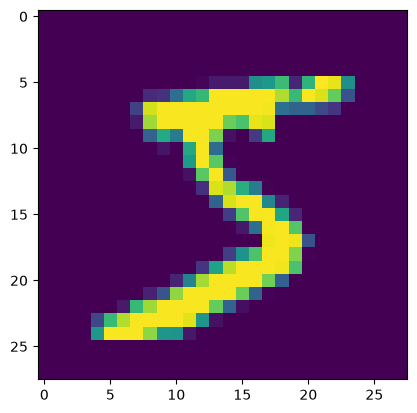

In [3]:
plt.imshow(x_train[0])

In [4]:
print(f"x_train shape: {x_train.shape}\ny_train shape: {y_train.shape}\nx_test shape: {x_test.shape}\ny_test shape: {y_test.shape}")

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [5]:
x_train = x_train.reshape(-1, 28*28) / 255.0
x_test = x_test.reshape(-1, 28*28) / 255.0
print(f"Normalized x_train: {x_train.shape}")
print(f"Normalized x_test: {x_test.shape}")

Normalized x_train: (60000, 784)
Normalized x_test: (10000, 784)


In [6]:
x = x_train[:1]
print(f"x shape: {x.shape}")

x shape: (1, 784)


In [7]:
w1 = np.random.randn(784, 128) * 0.01
b1 = np.zeros((1, 128))
print(f"w1 shape: {w1.shape}\nb1 shape: {b1.shape}")

w1 shape: (784, 128)
b1 shape: (1, 128)


In [8]:
z1 = np.dot(x, w1) + b1
a1 = np.maximum(0, z1)  # ReLU activation
print(f"z1 shape: {z1.shape}\na1 shape: {a1.shape}")
print(f"Max value in z1: {np.max(z1)}\nMin value in z1: {np.min(z1)}")
print(f"Max value in a1: {np.max(a1)}\nMin value in a1: {np.min(a1)}")

z1 shape: (1, 128)
a1 shape: (1, 128)
Max value in z1: 0.21352180130889312
Min value in z1: -0.1942400658745151
Max value in a1: 0.21352180130889312
Min value in a1: 0.0


In [9]:
w2 = np.random.randn(128, 10) * 0.01
b2 = np.zeros((1, 10))
z2 = np.dot(a1, w2) + b2
print(f"w2 shape: {w2.shape}\nb2 shape: {b2.shape}\nz2 shape: {z2.shape}")
print(f"Max value in z2: {np.max(z2)}\nMin value in z2: {np.min(z2)}")

w2 shape: (128, 10)
b2 shape: (1, 10)
z2 shape: (1, 10)
Max value in z2: 0.011718213034510634
Min value in z2: -0.010540724107118656


In [10]:
exp = np.exp(z2)
probablities_softmax = exp / np.sum(exp, axis=1, keepdims=True)
print(f"Probablities: {probablities_softmax}")
print(f"Probabilities shape: {probablities_softmax.shape}")
print(f"Max value in probabilities: {np.max(probablities_softmax)}\nMin value in probabilities: {np.min(probablities_softmax)}")
print(f"Sum of probabilities: {np.sum(probablities_softmax)}")

Probablities: [[0.09886898 0.10085573 0.10010671 0.0998507  0.10109437 0.10052174
  0.09992604 0.09915024 0.0994831  0.1001424 ]]
Probabilities shape: (1, 10)
Max value in probabilities: 0.10109437208423976
Min value in probabilities: 0.09886897814465297
Sum of probabilities: 0.9999999999999999


In [11]:
print(f"y_train1: {y_train[0]}")

y_train1: 5


In [14]:
correct_probablity = -np.log(probablities_softmax[0, y_train[0]])
print(f"Correct class: {y_train[0]}\nCorrect probability: {correct_probablity}")

Correct class: 5
Correct probability: 2.2973813003524355


In [15]:
loss = -np.log(correct_probablity)
print(f"Cross Entropy Loss: {loss}")

Cross Entropy Loss: -0.8317699092133368


In [17]:
y = np.zeros((1, 10))
y[0, y_train[0]] = 1
print(f"One-hot encoded y: {y}")

One-hot encoded y: [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]]


In [18]:
dz2 = probablities_softmax - y
print(f"dz2 shape: {dz2.shape}\nMax value in dz2: {np.max(dz2)}\nMin value in dz2: {np.min(dz2)}")
print(f"dz2: {dz2}")

dz2 shape: (1, 10)
Max value in dz2: 0.10109437208423976
Min value in dz2: -0.8994782644112895
dz2: [[ 0.09886898  0.10085573  0.10010671  0.0998507   0.10109437 -0.89947826
   0.09992604  0.09915024  0.0994831   0.1001424 ]]


In [19]:
dw2 = np.dot(a1.T, dz2)
db2 = np.sum(dz2, axis=0, keepdims=True)
print(f"dw2 shape: {dw2.shape}\ndb2 shape: {db2.shape}")
print(f"Max value in dw2: {np.max(dw2)}\nMin value in dw2: {np.min(dw2)}")
print(f"Max value in db2: {np.max(db2)}\nMin value in db2: {np.min(db2)}")

dw2 shape: (128, 10)
db2 shape: (1, 10)
Max value in dw2: 0.02158585242961835
Min value in dw2: -0.1920582192552954
Max value in db2: 0.10109437208423976
Min value in db2: -0.8994782644112895


In [21]:
da1 = np.dot(dz2, w2.T)
dz1 = da1 * (z1 > 0)  # Derivative of ReLU
print(f"da1 shape: {da1.shape}\ndz1 shape: {dz1.shape}")
print(f"Max value in da1: {np.max(da1)}\nMin value in da1: {np.min(da1)}")
print(f"Max value in dz1: {np.max(dz1)}\nMin value in dz1: {np.min(dz1)}")

da1 shape: (1, 128)
dz1 shape: (1, 128)
Max value in da1: 0.019210565564363517
Min value in da1: -0.02076233536240828
Max value in dz1: 0.018295032592907375
Min value in dz1: -0.02076233536240828


In [22]:
dw1 = np.dot(x.T, dz1)
db1 = np.sum(dz1, axis=0, keepdims=True)
print(f"dw1 shape: {dw1.shape}\ndb1 shape: {db1.shape}")
print(f"Max value in dw1: {np.max(dw1)}\nMin value in dw1: {np.min(dw1)}")
print(f"Max value in db1: {np.max(db1)}\nMin value in db1: {np.min(db1)}")

dw1 shape: (784, 128)
db1 shape: (1, 128)
Max value in dw1: 0.018295032592907375
Min value in dw1: -0.02076233536240828
Max value in db1: 0.018295032592907375
Min value in db1: -0.02076233536240828


In [23]:
learning_rate = 0.01
w1 -= learning_rate * dw1
b1 -= learning_rate * db1
w2 -= learning_rate * dw2
b2 -= learning_rate * db2